# Inspect ERA5 Data

In [4]:
import xarray as xr
ds = xr.open_dataset('https://gws-access.jasmin.ac.uk/public/eds_ai/era5_repack/aggregations/data/ecmwf-era5X_oper_an_sfc_2000_2020_2d_repack.kr1.0.json', engine='kerchunk')

# print(ds)

ds_small = ds.sel(
    time=slice("2005-01-01T00", "2005-01-01T02")
)

In [5]:
print("dataset \n ", ds)
print("dimension sizes \n", ds.dims)            # dimension sizes
print("variables \n", list(ds.data_vars))       # variables
print("coordinates \n",list(ds.coords))         # coordinates

dataset 
  <xarray.Dataset> Size: 765GB
Dimensions:    (time: 184104, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 1MB 2000-01-01 ... 2020-12-31T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    d2m        (time, latitude, longitude) float32 765GB ...
Attributes:
    Conventions:  CF-1.6
    history:      See hourly source files for details.,\n2026-01-19 13:40:58 ...
dimension sizes 
 FrozenMappingWarningOnValuesAccess({'time': 184104, 'latitude': 721, 'longitude': 1440})
variables 
 ['d2m']
coordinates 
 ['latitude', 'longitude', 'time']


In [6]:
print("dataset \n ", ds_small)
print("dimension sizes \n", ds_small.dims)            # dimension sizes
print("variables \n", list(ds_small.data_vars))       # variables
print("coordinates \n",list(ds_small.coords))         # coordinates

dataset 
  <xarray.Dataset> Size: 12MB
Dimensions:    (time: 3, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 24B 2005-01-01 ... 2005-01-01T02:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    d2m        (time, latitude, longitude) float32 12MB ...
Attributes:
    Conventions:  CF-1.6
    history:      See hourly source files for details.,\n2026-01-19 13:40:58 ...
dimension sizes 
 FrozenMappingWarningOnValuesAccess({'time': 3, 'latitude': 721, 'longitude': 1440})
variables 
 ['d2m']
coordinates 
 ['latitude', 'longitude', 'time']


# What are different variables?

In [34]:
print(ds_small.attrs)          # global dataset attrs
print(ds_small["d2m"].attrs)   # example variable attrs (if t2m exists)

{'Conventions': 'CF-1.6', 'history': 'See hourly source files for details.,\n2026-01-19 13:40:58 GMT Repacked for FRAME-FM AI Project Applications (https://github.com/dwest77a/era5_repack)'}
{'units': 'K', 'long_name': '2 metre dewpoint temperature'}


In [35]:
for v in ds_small.data_vars:
    print(v, ds_small[v].attrs.get("long_name"), ds_small[v].attrs.get("units"))

d2m 2 metre dewpoint temperature K


In [36]:
#Peek at coordinate values (safe, usually small)

print(ds_small["time"].values, ds_small["time"].values)
print(ds_small["latitude"].values[:], ds_small["longitude"].values[:])

['2005-01-01T00:00:00.000000000' '2005-01-01T01:00:00.000000000'
 '2005-01-01T02:00:00.000000000'] ['2005-01-01T00:00:00.000000000' '2005-01-01T01:00:00.000000000'
 '2005-01-01T02:00:00.000000000']
[ 90.    89.75  89.5   89.25  89.    88.75  88.5   88.25  88.    87.75
  87.5   87.25  87.    86.75  86.5   86.25  86.    85.75  85.5   85.25
  85.    84.75  84.5   84.25  84.    83.75  83.5   83.25  83.    82.75
  82.5   82.25  82.    81.75  81.5   81.25  81.    80.75  80.5   80.25
  80.    79.75  79.5   79.25  79.    78.75  78.5   78.25  78.    77.75
  77.5   77.25  77.    76.75  76.5   76.25  76.    75.75  75.5   75.25
  75.    74.75  74.5   74.25  74.    73.75  73.5   73.25  73.    72.75
  72.5   72.25  72.    71.75  71.5   71.25  71.    70.75  70.5   70.25
  70.    69.75  69.5   69.25  69.    68.75  68.5   68.25  68.    67.75
  67.5   67.25  67.    66.75  66.5   66.25  66.    65.75  65.5   65.25
  65.    64.75  64.5   64.25  64.    63.75  63.5   63.25  63.    62.75
  62.5   62.25  62.  

# Inspect variables, dimensions, coords

In [37]:
#Variables and their shapes/dtypes
for var in ds_small.data_vars:
    print(var)
    print(ds_small[var].dims)
    print(ds_small[var].shape)
    print(ds_small[var].dtype)

d2m
('time', 'latitude', 'longitude')
(3, 721, 1440)
float32


In [39]:
#Coordinates (time / lat / lon)

for coord in ds.coords:
    print(coord)
    print(ds_small[coord].dims)
    print(ds_small[coord].shape)
    print(ds_small[coord].dtype)

latitude
('latitude',)
(721,)
float32
longitude
('longitude',)
(1440,)
float32
time
('time',)
(3,)
datetime64[ns]


# What does each dimension represent?

In [ ]:
summary = []
for v in ds_small.data_vars:
    da = ds_small[v]
    summary.append({
        "var": v,
        "dims": da.dims,
        "shape": da.shape,
        "units": da.attrs.get("units"),
        "long_name": da.attrs.get("long_name")
    })
summary[:5]


[{'var': 'd2m',
  'dims': ('time', 'latitude', 'longitude'),
  'shape': (3, 721, 1440),
  'units': 'K',
  'long_name': '2 metre dewpoint temperature'}]

# How is it chunked?

In [ ]:
ds_small['d2m'].chunks 

Not chunked but can see all the data inside

In [46]:
ds_small["d2m"].data

array([[[245.3283 , 245.3283 , 245.3283 , ..., 245.3283 , 245.3283 ,
         245.3283 ],
        [246.07843, 246.07843, 246.07843, ..., 246.07843, 246.07843,
         246.07843],
        [246.54758, 246.54758, 246.54758, ..., 246.54758, 246.54758,
         246.54758],
        ...,
        [246.38722, 246.38457, 246.38457, ..., 246.38722, 246.38722,
         246.38722],
        [246.35806, 246.35806, 246.35806, ..., 246.35939, 246.35939,
         246.35939],
        [246.01349, 246.01349, 246.01349, ..., 246.01349, 246.01349,
         246.01349]],

       [[245.32741, 245.32741, 245.32741, ..., 245.32741, 245.32741,
         245.32741],
        [245.96779, 245.96779, 245.96779, ..., 245.96779, 245.96779,
         245.96779],
        [246.45633, 246.45633, 246.45633, ..., 246.45897, 246.45633,
         246.45633],
        ...,
        [246.17377, 246.17377, 246.17377, ..., 246.17508, 246.17508,
         246.17377],
        [246.16585, 246.16585, 246.16585, ..., 246.16585, 246.16585,
   

Above are all the variable values in the shape (time, lat, lon) and then the value. 

# Map at one timestep

In [49]:
ds_small["d2m"].isel(time=1)

<xarray.DataArray 'd2m' (latitude: 721, longitude: 1440)> Size: 4MB
array([[245.32741, 245.32741, 245.32741, ..., 245.32741, 245.32741, 245.32741],
       [245.96779, 245.96779, 245.96779, ..., 245.96779, 245.96779, 245.96779],
       [246.45633, 246.45633, 246.45633, ..., 246.45897, 246.45633, 246.45633],
       ...,
       [246.17377, 246.17377, 246.17377, ..., 246.17508, 246.17508, 246.17377],
       [246.16585, 246.16585, 246.16585, ..., 246.16585, 246.16585, 246.16585],
       [245.845  , 245.845  , 245.845  , ..., 245.845  , 245.845  , 245.845  ]],
      shape=(721, 1440), dtype=float32)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 2005-01-01T01:00:00
Attributes:
    units:      K
    long_name:  2 metre dewpoint temperature

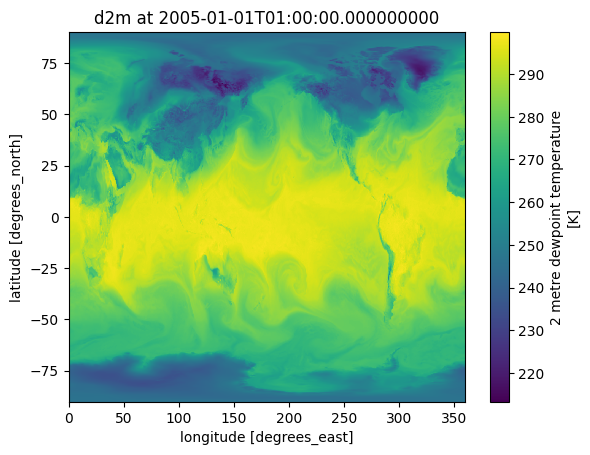

In [57]:
#Map at one timestep
import matplotlib.pyplot as plt
da0 = ds_small["d2m"].isel(time=1)
da0.plot()
plt.title(f"d2m at {str(da0['time'].values)}")
plt.show()

# Map for a box

In [84]:
ds.latitude.values[:10]

array([90.  , 89.75, 89.5 , 89.25, 89.  , 88.75, 88.5 , 88.25, 88.  ,
       87.75], dtype=float32)

If the above is descending (90 → -90) -> slice(max_lat, min_lat) If ascending slice(min_lat, max_lat)

In [ ]:
#Plot

lat_min, lat_max = 23, 30
lon_min, lon_max = 69, 78

def convert_lon(lon):
    if lon < 0:
        return lon + 360
    return lon

# convert longitudes if needed
lon_min = convert_lon(lon_min)
lon_max = convert_lon(lon_max)

if ds_small.latitude.values[0] > ds_small.latitude.values[-1]:
    # descending
    lat_slice = slice(lat_max, lat_min)
else:
    lat_slice = slice(lat_min, lat_max)

region = ds_small["d2m"].sel(
    latitude=lat_slice,
    longitude=slice(lon_min, lon_max)
)


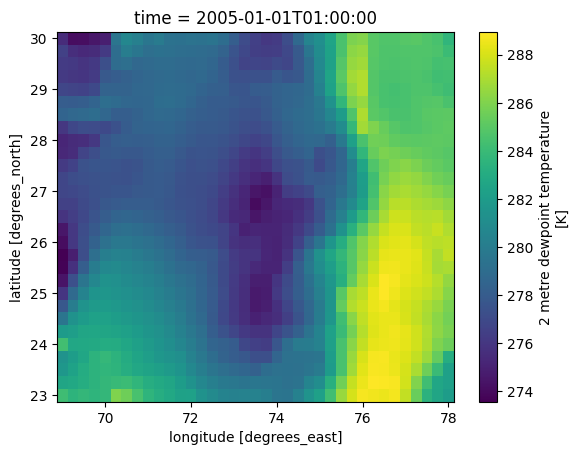

In [82]:
region.isel(time = 1).plot()

# Map at a point

Glasgow - 55.86407092441483, -4.294558946531613 (lat, lon)

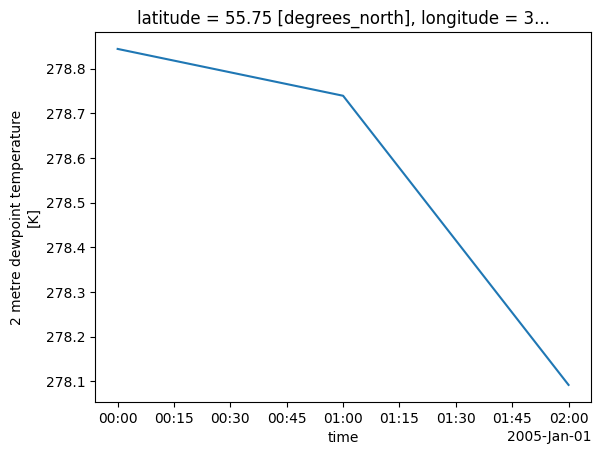

In [90]:
lat = 55.86407092441483
lon = -4.294558946531613

lon = convert_lon(lon)

point = ds_small["d2m"].sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

point.plot()